# Pie chart of mn counts

In [1]:
import os
import pandas as pd
import numpy as np
import skimage
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

- color schemes

In [2]:
datasets_colors = {'BBBC039':'#FFC0CB',
                   'mnfinder_train':'#80ED99',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

objects_color = {'Nuc':'#00A3FF',
                 'MN':'#A68CFF'}

# plt.rcParams.update({'font.size':12})

sns.set(font_scale=1.5, style='white')

- Count number of micronuclei annotations per each dataset

In [3]:
path = '/scr/yren/cleaned_annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))
df = df[df.split == 'train'] # only draw training set
df.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.50,train,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.50,train,RPE1
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa


In [4]:
print(df.shape)

(121, 6)


In [5]:
df_sub = df.loc[df.split == 'train', ['filenames', 'datasets']].copy().reset_index(drop=True)
train_mn_mask_path = os.path.join(path, 'train', 'mn_masks')

for i in range(df_sub.shape[0]):
    mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_sub.loc[i, 'filenames'].replace('.tif', '.png')))
    labels = skimage.measure.label(mn_mask)
    num_of_mn = np.max(labels) # maximal label is the total number of micronuclei
    df_sub.loc[i, 'num_of_mn'] = num_of_mn

Subset: BBBC039, Total num of MN: 488.0
Subset: mnfinder_train, Total num of MN: 1749.0
Subset: mnDINO_data_01, Total num of MN: 1021.0
Subset: mnDINO_data_02, Total num of MN: 149.0


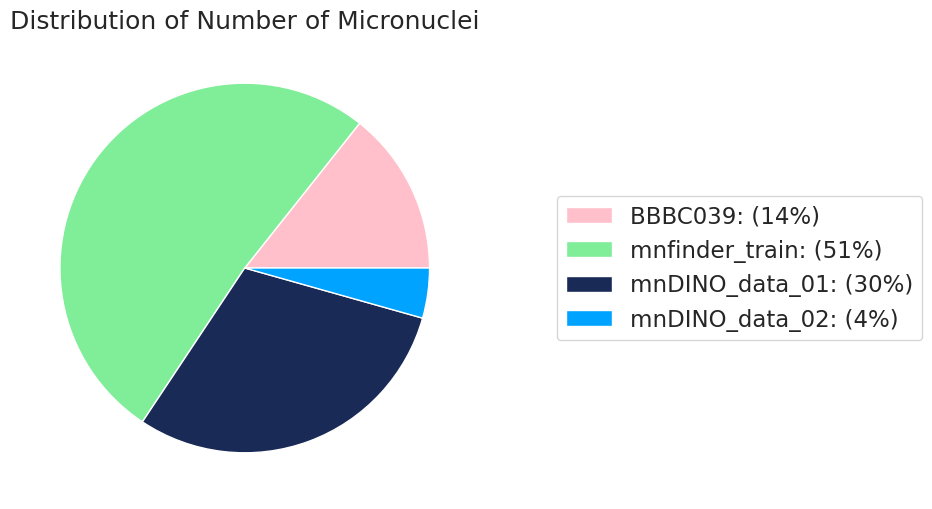

In [6]:
labels = ['BBBC039', 'mnfinder_train', 'mnDINO_data_01', 'mnDINO_data_02']
color_map_list = [datasets_colors[label] for label in labels]

counts = []

for subset in labels:
    total_mn = df_sub.loc[df_sub.datasets == subset, 'num_of_mn'].sum()
    print(f'Subset: {subset}, Total num of MN: {total_mn}')
    counts.append(total_mn)

# customize legend
total = sum(counts)
percentages = [f'{c / total * 100:.0f}%' for c in counts]
legend_labels = [f'{label}: ({pct})' for label, pct in zip(labels, percentages)]

fig, ax = plt.subplots(figsize=(10, 6))
patches, texts = ax.pie(counts, labels=None, autopct=None, colors=color_map_list) # autopct=None to disable
ax.legend(patches, legend_labels, loc='center left', bbox_to_anchor=(1.15, 0.5))

plt.title('Distribution of Number of Micronuclei')
plt.show()

In [7]:
percentages

['14%', '51%', '30%', '4%']

# Count micronucleated cells

- Use Euclidean distance to find the nucleated cell ID, save the dataframe!

In [8]:
df[df.datasets == 'mnDINO_data_01']

,filenames,datasets,magnification,micron,split,cell_line
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa
12,20X_c0-DAPI_A1_Tile-70.tif,mnDINO_data_01,14,4.25,train,HeLa
13,20X_c0-DAPI_A1_Tile-110.tif,mnDINO_data_01,14,4.25,train,HeLa
14,20X_c0-DAPI_A1_Tile-10.tif,mnDINO_data_01,14,4.25,train,HeLa
16,C2-20X_c0-DAPI-GFP_B1_Tile-8.tif,mnDINO_data_01,14,4.25,train,HeLa
17,C2-20X_c0-DAPI-GFP_A3_Tile-6.tif,mnDINO_data_01,14,4.25,train,HeLa
18,C2-20X_c0-DAPI-GFP_A1_Tile-17.tif,mnDINO_data_01,14,4.25,train,HeLa
20,20X_c0-DAPI_A1_Tile-30.tif,mnDINO_data_01,14,4.25,train,HeLa


In [9]:
import numpy as np
import skimage.io
import skimage.measure
from scipy.spatial import KDTree
from skimage.measure import regionprops

PATH = '/scr/yren/cleaned_annotated_mn_datasets/train/mn_masks/'
DF_PATH = '/scr/yren/cleaned_annotated_mn_datasets/'
df = pd.read_csv(os.path.join(DF_PATH, 'metadata.csv'))
df = df.loc[df.split == 'train']
all_cells = []

for i, row in tqdm(df.iterrows()):
    subset = row['datasets']
    image_id = row['filenames']
    # for each image, identify number of nucleated cells and then move to next one
    mn_mask = skimage.io.imread(os.path.join(PATH, image_id.replace('.tif', '.png')))
    nuc_mask = skimage.io.imread(os.path.join(PATH.replace('mn_masks', 'nuclei_masks'), image_id))

    mn_labels = skimage.morphology.label(mn_mask)
    nuc_labels = skimage.morphology.label(nuc_mask)

    mn_props = regionprops(mn_labels)
    nuc_props = regionprops(nuc_labels)


    mn_centroids = np.array([prop.centroid for prop in mn_props])
    nuc_centroids = np.array([prop.centroid for prop in nuc_props])

    nuc_ids = np.array([prop.label for prop in nuc_props])

    tree = KDTree(nuc_centroids) # k=1 means find the single closest neighbor
    # print(image_id)
    distances, indices = tree.query(mn_centroids, k=1)
    matched_nuc_ids = nuc_ids[indices]


    final_matches = []

    for i, mn_prop in enumerate(mn_props):
        result = {
            'mn_id': mn_prop.label,
            'closest_nuc_id': matched_nuc_ids[i],
            'distance': distances[i]
        }
        final_matches.append(result)

    cells = []
    for match in final_matches:
        cells.append(match['closest_nuc_id'].item())
        

    num_nucleated_cells = len(np.unique(cells))
    d = {'filenames':image_id ,'datasets':subset, 'num_micronucleated_cells':num_nucleated_cells}
    all_cells.append(d)

df = pd.DataFrame(all_cells)

0it [00:00, ?it/s]

121it [00:05, 21.44it/s]


In [10]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/micronucleated_cells.csv'
df.to_csv(SAVE_PATH, index=False)

In [11]:
micronucleated = pd.read_csv(SAVE_PATH)
micronucleated

,filenames,datasets,num_micronucleated_cells
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,61
1,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,57
2,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,58
3,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,78
4,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,87
...,...,...,...
116,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,9
117,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,6
118,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,21
119,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,5


# Table of Statistics

In [12]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/micronucleated_cells.csv'
micronucleated = pd.read_csv(SAVE_PATH)
micronucleated

,filenames,datasets,num_micronucleated_cells
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,61
1,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,57
2,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,58
3,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,78
4,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,87
...,...,...,...
116,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,9
117,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,6
118,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,21
119,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,5


In [13]:
path = '/scr/yren/cleaned_annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))
df_train = df.loc[df.split == 'train', ['filenames', 'datasets']].copy().reset_index(drop=True)
train_mn_mask_path = os.path.join(path, 'train', 'mn_masks')
train_nuc_mask_path = os.path.join(path, 'train', 'nuclei_masks')

for i in range(df_train.shape[0]):
    mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_train.loc[i, 'filenames'].replace('.tif', '.png')))
    mn_labels = skimage.measure.label(mn_mask)
    num_of_mn = np.max(mn_labels) # maximal label is the total number of micronuclei
    
    nuc_mask = skimage.io.imread(os.path.join(train_nuc_mask_path, df_train.loc[i, 'filenames']))
    nuc_labels = skimage.measure.label(nuc_mask)
    num_of_nuclei = np.max(nuc_labels)
    
    df_train.loc[i, 'num_of_mn'] = num_of_mn
    df_train.loc[i, 'num_of_nuc'] = num_of_nuclei

In [14]:
df_train

,filenames,datasets,num_of_mn,num_of_nuc
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,69.0,618.0
1,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,80.0,432.0
2,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,75.0,742.0
3,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,86.0,1390.0
4,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,108.0,905.0
...,...,...,...,...
116,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,12.0,85.0
117,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,6.0,126.0
118,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,39.0,39.0
119,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,5.0,125.0


In [15]:
# merge two dataframe by filenames column
table = df_train.merge(micronucleated[['filenames', 'num_micronucleated_cells']], on='filenames', how='left')

In [16]:
table

,filenames,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,69.0,618.0,61
1,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,80.0,432.0,57
2,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,75.0,742.0,58
3,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,86.0,1390.0,78
4,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,108.0,905.0,87
...,...,...,...,...,...
116,IXMtest_N15_s3_w148785C31-5B78-47BA-8802-FB8F2...,BBBC039,12.0,85.0,9
117,IXMtest_I15_s8_w196F01FA4-CE06-44AE-AAA5-ADEC3...,BBBC039,6.0,126.0,6
118,IXMtest_H06_s6_w1C3C98946-0210-4D6A-831E-56814...,BBBC039,39.0,39.0,21
119,IXMtest_H06_s4_w16261E805-AF5F-4785-BB65-C77B6...,BBBC039,5.0,125.0,5


In [17]:
table = table.drop(columns=['filenames']).groupby('datasets').sum().reset_index()
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells
0,BBBC039,488.0,7706.0,399
1,mnDINO_data_01,1021.0,11803.0,906
2,mnDINO_data_02,149.0,1050.0,118
3,mnfinder_train,1749.0,2171.0,1148


In [18]:
table['micronucleation_ratio'] = table['num_micronucleated_cells'] / table['num_of_nuc']

In [19]:
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells,micronucleation_ratio
0,BBBC039,488.0,7706.0,399,0.051778
1,mnDINO_data_01,1021.0,11803.0,906,0.076760
2,mnDINO_data_02,149.0,1050.0,118,0.112381
3,mnfinder_train,1749.0,2171.0,1148,0.528789


In [21]:
TABLE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/table_statistics/table.csv'
table.to_csv(TABLE_PATH, index=False)

In [22]:
table = pd.read_csv(TABLE_PATH)
table

,datasets,num_of_mn,num_of_nuc,num_micronucleated_cells,micronucleation_ratio
0,BBBC039,488.0,7706.0,399,0.051778
1,mnDINO_data_01,1021.0,11803.0,906,0.076760
2,mnDINO_data_02,149.0,1050.0,118,0.112381
3,mnfinder_train,1749.0,2171.0,1148,0.528789


In [23]:
table.sum()

datasets                    BBBC039mnDINO_data_01mnDINO_data_02mnfinder_train
num_of_mn                                                              3407.0
num_of_nuc                                                            22730.0
num_micronucleated_cells                                                 2571
micronucleation_ratio                                                0.769708
dtype: object

In [24]:
0.80656/4

0.20164

- Barplot

In [25]:
table_long = pd.melt(table.drop(columns=['num_of_mn', 'micronucleation_ratio']),
                     id_vars=['datasets'],
                     var_name='cell_status',
                     value_name='counts')

In [26]:
table_long

,datasets,cell_status,counts
0,BBBC039,num_of_nuc,7706.0
1,mnDINO_data_01,num_of_nuc,11803.0
2,mnDINO_data_02,num_of_nuc,1050.0
3,mnfinder_train,num_of_nuc,2171.0
4,BBBC039,num_micronucleated_cells,399.0
5,mnDINO_data_01,num_micronucleated_cells,906.0
6,mnDINO_data_02,num_micronucleated_cells,118.0
7,mnfinder_train,num_micronucleated_cells,1148.0


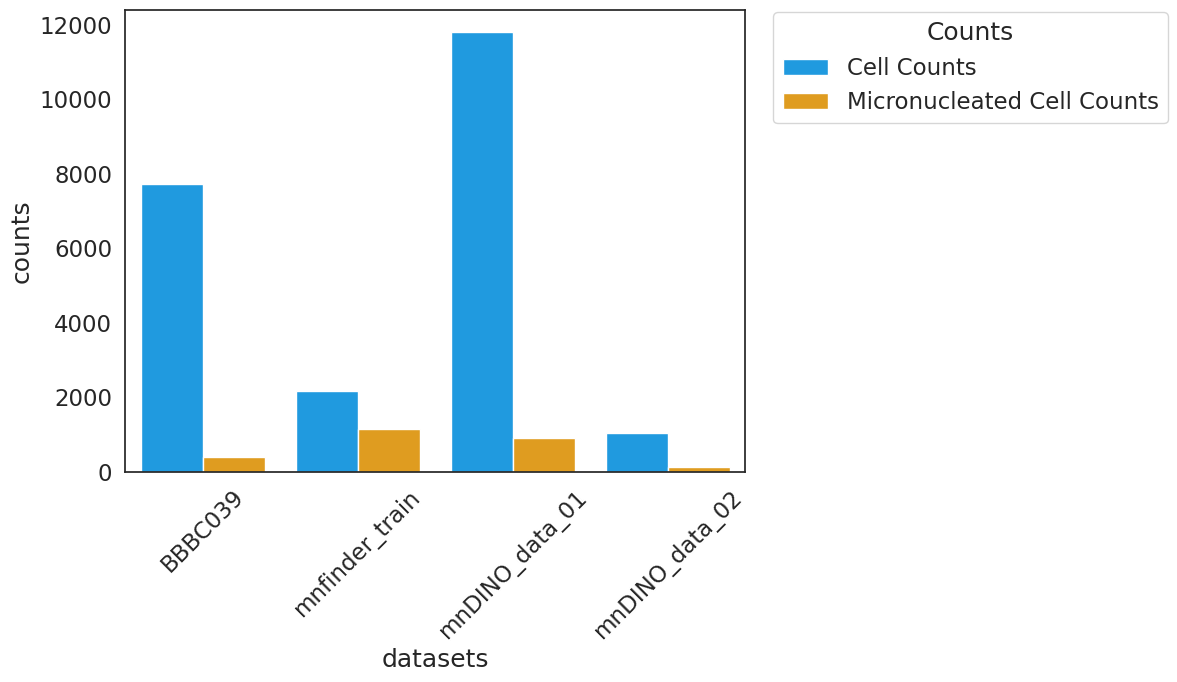

In [27]:
color = [objects_color['Nuc'], 'orange']
labels = ['BBBC039', 'mnfinder_train', 'mnDINO_data_01', 'mnDINO_data_02']

plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=table_long,
    x='datasets',
    y='counts',
    hue='cell_status',
    order=labels,
    palette=color
)

plt.xticks(rotation=45)

# Change Title and Labels
sns.move_legend(
    ax, 
    loc="upper right",
    bbox_to_anchor=(1.7,1.02),
    title="Counts",
    labels=["Cell Counts", "Micronucleated Cell Counts"]
)

plt.show()

# Histogram of mn size v.s. nuclei size for each subset

In [28]:
path = '/scr/yren/cleaned_annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))

In [29]:
labels = sorted(df[df.split == 'train'].datasets.unique().tolist())
print(labels)

all_data = []


for label in tqdm(labels):
    df_train = df.loc[(df.split == 'train') & (df.datasets == label), ['filenames', 'datasets', 'magnification', 'micron']].copy().reset_index()
    train_mn_mask_path = os.path.join(path, 'train', 'mn_masks')
    train_nuclei_mask_path = os.path.join(path, 'train', 'nuclei_masks')
    
    for i in range(df_train.shape[0]):
        mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_train.loc[i, 'filenames'].replace('.tif', '.png')))
        nuc_mask = skimage.io.imread(os.path.join(train_nuclei_mask_path, df_train.loc[i, 'filenames']))
        
        mag = df_train.loc[i, 'magnification']
        micron = df_train.loc[i, 'micron']

        mn_labels = skimage.morphology.label(mn_mask)
        nuc_labels = skimage.morphology.label(nuc_mask)

        
        for mn_id in range(1, np.max(mn_labels) + 1):
            mn_area = np.sum(mn_labels == mn_id)
            all_data.append({"Dataset":label, "ImageID":df_train.loc[i,"filenames"],"Type":"MN", "Area": int(mn_area), "Magnification":mag, "Micron":micron})
        
        for nuc_id in range(1, np.max(nuc_labels) + 1):
            ys, xs = np.where(nuc_labels == nuc_id)
            y, x = np.mean(ys), np.mean(xs)
            
            # filter out margin cases
            if not ((y - 25 <= 0) | (y + 25 >= nuc_mask.shape[0]) | (x - 25 <= 0) | (x + 25 >= nuc_mask.shape[1])):
                nuc_area = np.sum(nuc_labels == nuc_id)
                all_data.append({"Dataset":label, "ImageID":df_train.loc[i,"filenames"],"Type":"Nuc", "Area": int(nuc_area), "Magnification":mag, "Micron":micron})
            

all_data = pd.DataFrame(all_data)

['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train']


100%|██████████| 4/4 [06:36<00:00, 99.21s/it] 


- Filter out nuclei area that is less than 10 $\text{pixel}^2$, consider them as artifact/noise

In [30]:
all_data = all_data[
    (all_data.Type == 'MN') | 
    ((all_data.Type == 'Nuc') & (all_data.Area > 10))
]

In [31]:
all_data[(all_data.Area < 5) & (all_data.Dataset.isin(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02']))]

,Dataset,ImageID,Type,Area,Magnification,Micron


In [32]:
# Save area_distribution.csv
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/area_distribution.csv'
all_data.to_csv(SAVE_PATH, index=False)

In [33]:
SAVE_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/distribution_plot/area_distribution.csv'
all_data = pd.read_csv(SAVE_PATH)
all_data.head(3)

,Dataset,ImageID,Type,Area,Magnification,Micron
0,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1
1,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1
2,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1


- align data to our magnification (so the x-axis unit is micron)

Pixel Length ($\mu$ m/pixel) = Camera Pixel Size / Magnification

Pixel Area = $\text{Pixel Length}^{2}$

In [34]:
all_data[all_data.Type=='MN']

,Dataset,ImageID,Type,Area,Magnification,Micron
0,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1
1,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1
2,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1
3,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1
4,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,16,20,13.1
...,...,...,...,...,...,...
23265,mnfinder_train,2022-05-25_RPE1-1.tif,MN,6,20,13.0
23266,mnfinder_train,2022-05-25_RPE1-1.tif,MN,16,20,13.0
23267,mnfinder_train,2022-05-25_RPE1-1.tif,MN,43,20,13.0
23268,mnfinder_train,2022-05-25_RPE1-1.tif,MN,16,20,13.0


In [35]:
all_data['Aligned_Area'] = all_data['Area'] * ((all_data['Micron'] / all_data['Magnification']) ** 2)

In [36]:
all_data[all_data.Dataset=='mnfinder_train']

,Dataset,ImageID,Type,Area,Magnification,Micron,Aligned_Area
19815,mnfinder_train,2022-05-27_RPE1-3.tif,MN,13,20,13.0,5.4925
19816,mnfinder_train,2022-05-27_RPE1-3.tif,MN,34,20,13.0,14.3650
19817,mnfinder_train,2022-05-27_RPE1-3.tif,MN,10,20,13.0,4.2250
19818,mnfinder_train,2022-05-27_RPE1-3.tif,MN,29,20,13.0,12.2525
19819,mnfinder_train,2022-05-27_RPE1-3.tif,MN,4,20,13.0,1.6900
...,...,...,...,...,...,...,...
23374,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,287,20,13.0,121.2575
23375,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,502,20,13.0,212.0950
23376,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,278,20,13.0,117.4550
23377,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,567,20,13.0,239.5575


In [37]:
all_data[(all_data.Type == 'Nuc') & (all_data.Aligned_Area < 20)].groupby('ImageID').count()

,Dataset,Type,Area,Magnification,Micron,Aligned_Area
ImageID,,,,,,
2022-05-27_RPE1-1.tif,2,2,2,2,2,2
20X_c0-DAPI_A1_Tile-10.tif,1,1,1,1,1,1
20X_c0-DAPI_A1_Tile-110.tif,1,1,1,1,1,1
20X_c0-DAPI_A1_Tile-70.tif,2,2,2,2,2,2
20X_c0-DAPI_A1_Tile-90.tif,1,1,1,1,1,1
C2-20X_c0-DAPI-GFP_A1_Tile-17.tif,1,1,1,1,1,1
C2-20X_c0-DAPI-GFP_B3_Tile-10.tif,1,1,1,1,1,1


Text(0.5, 1.0, 'Area Distributions aligned in microns')

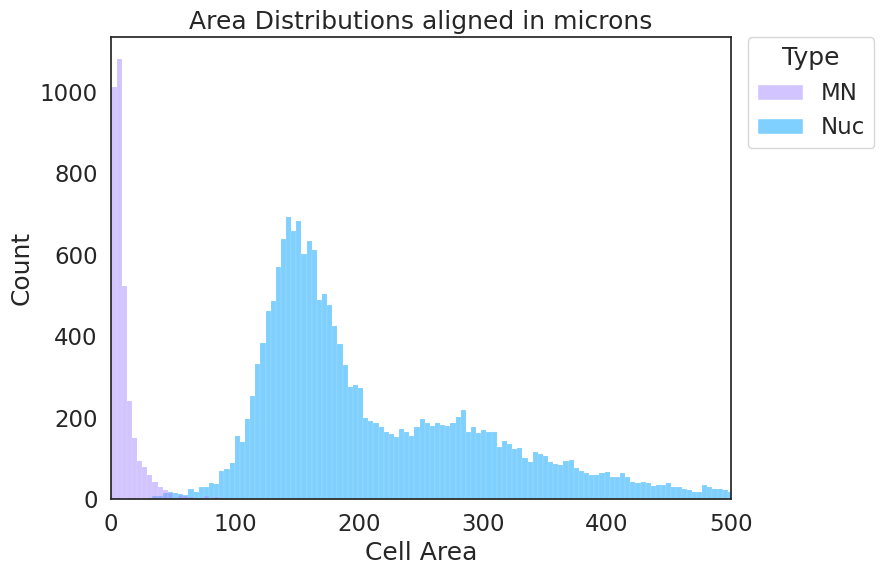

In [38]:
plt.figure(figsize=(8,6))
ax = sns.histplot(data=all_data, x="Aligned_Area", hue="Type", fill=True, bins=600, palette=objects_color)
plt.xlabel('Cell Area')
plt.xlim(0, 500)
# plt.ylim(0, 1000)
sns.move_legend(obj=ax,
                loc='upper right',
                bbox_to_anchor=(1.25,1.025))

plt.title('Area Distributions aligned in microns')

In [39]:
all_data

,Dataset,ImageID,Type,Area,Magnification,Micron,Aligned_Area
0,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1,5.148300
1,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,12,20,13.1,5.148300
2,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1,7.293425
3,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,17,20,13.1,7.293425
4,BBBC039,IXMtest_A20_s4_w153DE191F-B112-471B-AC0A-FAD27...,MN,16,20,13.1,6.864400
...,...,...,...,...,...,...,...
23374,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,287,20,13.0,121.257500
23375,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,502,20,13.0,212.095000
23376,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,278,20,13.0,117.455000
23377,mnfinder_train,2022-05-25_RPE1-1.tif,Nuc,567,20,13.0,239.557500


Text(0.5, 1.0, 'Micronuclei Area Distributions aligned in microns')

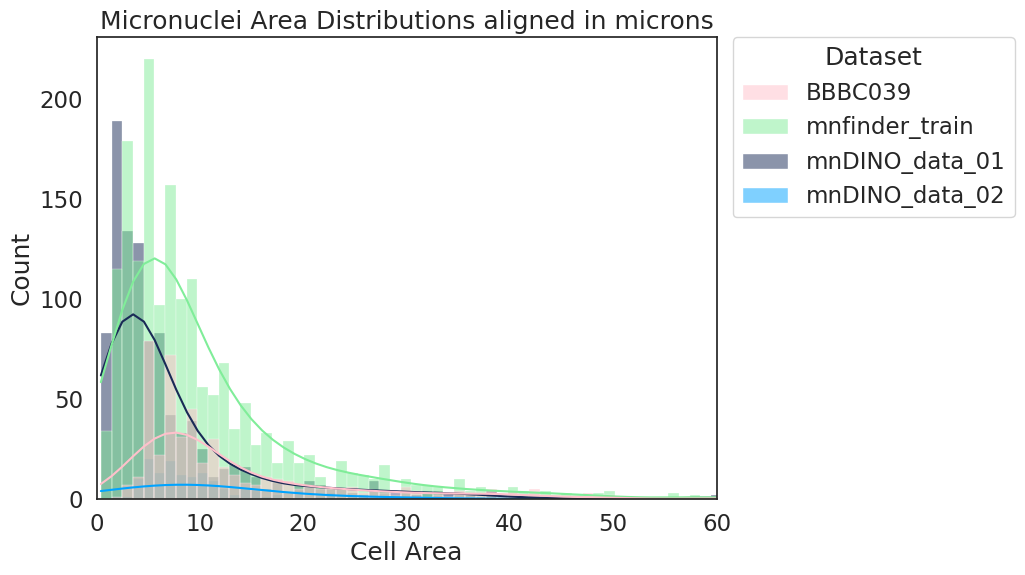

In [40]:
plt.figure(figsize=(8,6))
labels = ['BBBC039', 'mnfinder_train', 'mnDINO_data_01', 'mnDINO_data_02']
ax = sns.histplot(data=all_data[all_data.Type=='MN'], 
             x="Aligned_Area", 
             hue="Dataset", 
             hue_order=labels,
             fill=True, 
             alpha=0.5, 
             bins=200,
             kde=True,
             palette=datasets_colors)
plt.xlabel('Cell Area')
plt.xlim(0, 60)

sns.move_legend(obj=ax,
                loc='upper right',
                bbox_to_anchor=(1.5,1.025))

plt.title('Micronuclei Area Distributions aligned in microns')

In [45]:
# sorted(all_data[all_data.Dataset.isin(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02'])].Area.to_list())

/tmp/ipykernel_2456936/867435454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=all_data[all_data.Type=='MN'],


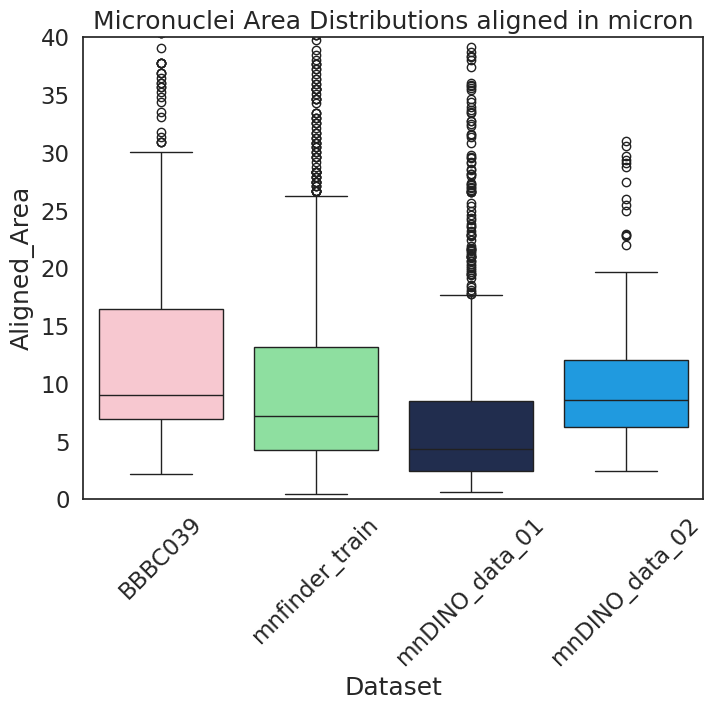

In [ ]:
plt.figure(figsize=(8, 6))

ax = sns.boxplot(data=all_data[all_data.Type=='MN'],
            x='Dataset',
            y='Aligned_Area',
            order=['BBBC039', 'mnfinder_train', 'mnDINO_data_01', 'mnDINO_data_02'],
            palette=datasets_colors)

plt.ylim(0, 40)

plt.xticks(rotation=45)
plt.title('Micronuclei Area Distributions aligned in micron')
plt.show()